# Operations, Monitoring & Evidence 
## Stage 4 · serve → containerise → automate → monitor → retrain → govern  <font color="red">[25 marks]</font>

- Each stage lists its **sub-tasks as a checklist**
- Implement reusable logic in `app.py`, `src/monitoring.py` and `src/retrain.py`.

**File ownership** —
- *Provided:* `src/generate_current_batch.py`, `src/evaluate.py`, `tests/`, `Dockerfile`, `.github/workflows/ci.yml`, `requirements.txt`
- *You create/extend:* `app.py`, `src/monitoring.py`, `src/retrain.py` and the cells below. 
- Run after the Stage-3 notebook.

## Stage 4.1 — API Deployment <font color="red">[5 marks]</font>

- **4.1.1 — FastAPI inference service (/predict + /health + validation) [3]** *(graded from `app.py`)* — POST `/predict` (probability + label) with request validation + missing-field handling, and GET `/health`.
- **4.1.2 — Live request/response demonstrated in-notebook [2]** *(graded from this notebook)* — call `/health` and `/predict` via `fastapi.testclient.TestClient` and show the JSON.

In [1]:
# TODO 4.1.1 (app.py): FastAPI with GET /health + POST /predict, loading the model from
#   artifacts/registry, with request validation + missing-field handling.
# TODO 4.1.2 (here): use TestClient to call /health and /predict; show the responses.


# Stage 4.1.2 — Live FastAPI Request / Response Evidence


import json
import importlib
import pandas as pd

from fastapi.testclient import TestClient

import app as app_module


# Reload latest app.py
importlib.reload(app_module)

client = TestClient(app_module.app)



# 1. Test GET /health


health_response = client.get("/health")

print("GET /health")
print("Status Code:", health_response.status_code)
print("Response:")
print(
    json.dumps(
        health_response.json(),
        indent=4
    )
)



# 2. Prepare one realistic input record


reference_df = pd.read_csv(
    "artifacts/reference_sample.csv"
)

with open(
    "artifacts/input_columns.json",
    "r",
    encoding="utf-8"
) as f:
    input_columns = json.load(f)


# Take one reference row
sample_df = reference_df[
    input_columns
].head(1)


# Convert safely to JSON-compatible Python values.
# NaN becomes null automatically.
sample_features = json.loads(
    sample_df.to_json(
        orient="records"
    )
)[0]


print("\nNumber of input features:")
print(len(sample_features))



# 3. Test POST /predict


predict_response = client.post(
    "/predict",
    json={
        "features": sample_features
    }
)


print("\nPOST /predict")
print(
    "Status Code:",
    predict_response.status_code
)

print("Response:")
print(
    json.dumps(
        predict_response.json(),
        indent=4
    )
)



# 4. Demonstrate validation


invalid_response = client.post(
    "/predict",
    json={
        "features": {}
    }
)


print(
    "\nPOST /predict — Empty Features Validation"
)

print(
    "Status Code:",
    invalid_response.status_code
)

print("Response:")
print(
    json.dumps(
        invalid_response.json(),
        indent=4
    )
)

GET /health
Status Code: 200
Response:
{
    "status": "ok",
    "model_loaded": true,
    "input_columns_loaded": true
}

Number of input features:
39

POST /predict
Status Code: 200
Response:
{
    "readmission_probability": 0.46232245678432826,
    "readmitted_30d": 0,
    "threshold": 0.5
}

POST /predict — Empty Features Validation
Status Code: 422
Response:
{
    "detail": "features must not be empty"
}


## Stage 4.2 — Containerisation <font color="red">[4 marks]</font>

- **4.2.1 — Valid Dockerfile [2]** — `FROM python`, installs `libgomp1` (XGBoost), `pip install -r requirements.txt`, `CMD uvicorn`.
- **4.2.2 — Build/run evidence [2]** — a `docker build` log excerpt/screenshot + a sample `curl` response from the running container.

In [9]:
# TODO 4.2.1: print your Dockerfile (Path('Dockerfile').read_text()).
# TODO 4.2.2: include build/run evidence (build screenshot/log + sample curl response).
#       (Remember libgomp1 is required for XGBoost in the image.)

# Stage 4.2 — Docker Containerisation Evidence


import subprocess
import json
import urllib.request

from pathlib import Path

print("=" * 70)
print("4.2.1 — DOCKERFILE")
print("=" * 70)

print(
    Path("Dockerfile").read_text(
        encoding="utf-8"
    )
)

print("\n" + "=" * 70)
print("4.2.2 — DOCKER BUILD / RUN EVIDENCE")
print("=" * 70)

def run_command(command):
    result = subprocess.run(
        command,
        shell=True,
        capture_output=True,
        text=True
    )

    print(f"\n$ {command}")

    if result.stdout:
        print(result.stdout)

    if result.stderr:
        print(result.stderr)

    return result.returncode



# 1. Verify Docker image


print("DOCKER IMAGE EVIDENCE")

run_command(
    "docker images hospital-readmission-api"
)



# 2. Verify running container


print("\nRUNNING CONTAINER EVIDENCE")

run_command(
    'docker ps --filter "name=hospital-readmission-container"'
)



# 3. Verify API running inside Docker


print("\nCONTAINER API HEALTH CHECK")

with urllib.request.urlopen(
    "http://localhost:8000/health"
) as response:

    health_data = json.loads(
        response.read().decode("utf-8")
    )

    print(
        "HTTP Status:",
        response.status
    )

    print(
        json.dumps(
            health_data,
            indent=4
        )
    )

4.2.1 — DOCKERFILE
# Hospital Readmission Prediction — inference service
FROM python:3.11-slim

# libgomp1 is required by xgboost at runtime
RUN apt-get update && apt-get install -y --no-install-recommends libgomp1 \
    && rm -rf /var/lib/apt/lists/*

WORKDIR /app
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

COPY app.py config.py ./
COPY src ./src
COPY artifacts ./artifacts

EXPOSE 8000
CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]


4.2.2 — DOCKER BUILD / RUN EVIDENCE
DOCKER IMAGE EVIDENCE

$ docker images hospital-readmission-api
REPOSITORY                 TAG       IMAGE ID       CREATED       SIZE
hospital-readmission-api   latest    58bf1ff564b3   2 hours ago   3.21GB


RUNNING CONTAINER EVIDENCE

$ docker ps --filter "name=hospital-readmission-container"
CONTAINER ID   IMAGE                      COMMAND                  CREATED             STATUS             PORTS                                         NAMES
5f0fc2a21699   hosp

## Stage 4.3 — CI/CD Automation <font color="red">[5 marks]</font>

- **4.3.1 — GitHub Actions workflow (install deps + run pytest) [3]** — installs dependencies and runs the test suite on push/PR (ideally also validates the Docker build).
- **4.3.2 — Passing-test evidence [2]** — pytest output run here AND/OR a screenshot of a green Actions run.

In [ ]:
# TODO 4.3.1: print your .github/workflows/ci.yml.
# TODO 4.3.2: run the test suite here (subprocess pytest) AND include a green-run screenshot.




# Stage 4.3 — CI/CD Automation Evidence


from pathlib import Path
import subprocess
import sys


#
# 4.3.1 — GitHub Actions workflow
#

print("=" * 70)
print("4.3.1 — GITHUB ACTIONS WORKFLOW")
print("=" * 70)

ci_file = Path(".github/workflows/ci.yml")

print(ci_file.read_text(encoding="utf-8"))


#
# 4.3.2 — Automated test evidence
#

print("\n" + "=" * 70)
print("4.3.2 — PYTEST EVIDENCE")
print("=" * 70)

result = subprocess.run(
    [
    sys.executable,
    "-m",
    "pytest",
    "tests/",
    "-q",
    "--color=no"
    ],
    capture_output=True,
    text=True
)

print(result.stdout)

if result.stderr:
    print(result.stderr)

print(
    "Pytest return code:",
    result.returncode
)

if result.returncode == 0:
    print("CI test status: PASS")
else:
    print("CI test status: FAIL")

4.3.1 — GITHUB ACTIONS WORKFLOW
name: ci

on:
  push:
    branches: [ main ]
  pull_request:

jobs:
  test:
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v4
      - uses: actions/setup-python@v5
        with:
          python-version: "3.11"
      - name: Install dependencies
        run: |
          python -m pip install --upgrade pip
          pip install -r requirements.txt
      - name: Run tests
        run: python -m pytest tests/ -q
      - name: Validate Docker build
        run: docker build -t readmission-api:ci .


4.3.2 — PYTEST EVIDENCE
...                                                                      [100%]
3 passed in 5.96s

Pytest return code: 0
CI test status: PASS


## Stage 4.4 — Monitoring & Drift Detection <font color="red">[4 marks]</font>

Implement `run_monitoring()` in `src/monitoring.py`.

- **4.4.1 — Feature drift (Evidently, reference vs current) [2]** — run an Evidently `DataDriftPreset` (reference vs current batch); summarise + visualise.
- **4.4.2 — Prediction drift (PSI on scores) + interpretation [2]** — compute PSI on model scores and interpret (prediction drift can exceed feature-level drift).

STAGE 4.4 — MONITORING & DRIFT DETECTION

Reference shape: (5000, 39)
Current shape: (5000, 39)
Number of monitored features: 39

Running Evidently feature drift...

Feature drift:
Drifted columns: 6/39
Share drifted: 0.1538
Dataset drift: False

Calculating prediction-score PSI...
Prediction PSI: 0.2850
Interpretation: Significant prediction drift detected (PSI > 0.20).

Saved: C:\Users\njoya\Documents\Upgrad-\CapStone\652768bd-9750-4c05-8e1c-9040b2c94574-Capstone-Implementation-Package\MLOps 1 - Starter\artifacts\drift_report.html
Saved: C:\Users\njoya\Documents\Upgrad-\CapStone\652768bd-9750-4c05-8e1c-9040b2c94574-Capstone-Implementation-Package\MLOps 1 - Starter\artifacts\drift_summary.json

Monitoring Summary:
{
    "number_of_drifted_columns": 6,
    "number_of_columns": 39,
    "share_drifted": 0.15384615384615385,
    "dataset_drift": false,
    "prediction_psi": 0.2850167054674114,
    "prediction_psi_interpretation": "Significant prediction drift detected (PSI > 0.20)."
}

ST

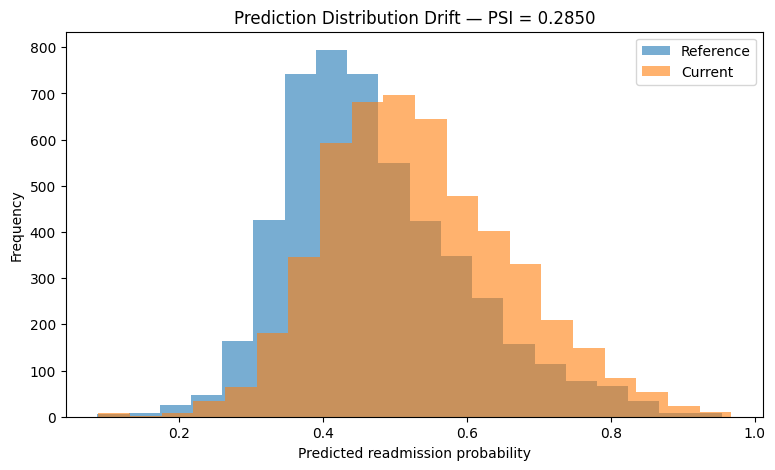

In [ ]:
# TODO 4.4.1: generate a current batch (src.generate_current_batch); run Evidently feature drift.
# TODO 4.4.2: compute prediction PSI on model scores; summarise, plot and interpret.

# Stage 4.4 — Monitoring & Drift Detection Evidence


import json
import joblib
import pandas as pd
import matplotlib.pyplot as plt

from src.monitoring import run_monitoring
import config as cfg


# Run monitoring workflow
summary = run_monitoring()


print("\n" + "=" * 65)
print("STAGE 4.4 INTERPRETATION")
print("=" * 65)

print(
    f"Feature drift: "
    f"{summary['number_of_drifted_columns']}/"
    f"{summary['number_of_columns']} features drifted."
)

print(
    f"Drifted feature share: "
    f"{summary['share_drifted']:.2%}"
)

print(
    "Dataset drift:",
    summary["dataset_drift"]
)

print(
    f"Prediction PSI: "
    f"{summary['prediction_psi']:.4f}"
)

print(
    "\nInterpretation:"
)

print(
    "Only a minority of individual features drifted, "
    "so Evidently did not flag overall dataset drift."
)

print(
    "However, prediction PSI exceeded 0.20, indicating "
    "significant drift in the model-output distribution."
)

print(
    "Therefore prediction drift can trigger retraining even "
    "when overall dataset drift is False."
)


#
# Visualise prediction-score drift
#

model = joblib.load(
    cfg.ARTIFACT_DIR / "best_model.pkl"
)

reference = pd.read_csv(
    cfg.ARTIFACT_DIR / "reference_sample.csv"
)

current = pd.read_csv(
    cfg.ARTIFACT_DIR / "current_batch.csv"
)

with open(
    cfg.ARTIFACT_DIR / "input_columns.json",
    "r",
    encoding="utf-8"
) as f:
    input_columns = json.load(f)


reference_scores = model.predict_proba(
    reference[input_columns]
)[:, 1]

current_scores = model.predict_proba(
    current[input_columns]
)[:, 1]


plt.figure(figsize=(9, 5))

plt.hist(
    reference_scores,
    bins=20,
    alpha=0.6,
    label="Reference"
)

plt.hist(
    current_scores,
    bins=20,
    alpha=0.6,
    label="Current"
)

plt.xlabel("Predicted readmission probability")
plt.ylabel("Frequency")
plt.title(
    f"Prediction Distribution Drift — PSI = "
    f"{summary['prediction_psi']:.4f}"
)

plt.legend()
plt.show()

## Stage 4.5 — Retraining Workflow <font color="red">[3 marks]</font>

Implement the trigger + workflow in `src/retrain.py`.

- **4.5.1 — Multi-signal retraining trigger defined [1]** — prediction PSI > 0.2 OR drifted share > 0.3 OR dataset drift.
- **4.5.2 — Retraining workflow runs + re-registers + decision record [2]** — on a trigger, retrain + register a new version and record the decision (`retraining_decision.json`).

In [ ]:
# TODO 4.5.1: define the multi-signal trigger.
# TODO 4.5.2: on a trigger, retrain + register a new version; show the decision record.

# Stage 4.5 — Retraining Workflow Evidence


import json

import mlflow
from mlflow import MlflowClient

import config as cfg
from src.retrain import decide


#
# Load monitoring summary
#

with open(
    cfg.ARTIFACT_DIR / "drift_summary.json",
    "r",
    encoding="utf-8"
) as f:
    drift_summary = json.load(f)


print("=" * 65)
print("4.5.1 — MULTI-SIGNAL RETRAINING TRIGGER")
print("=" * 65)

print(
    "Prediction PSI:",
    drift_summary["prediction_psi"]
)

print(
    "Drifted feature share:",
    drift_summary["share_drifted"]
)

print(
    "Dataset drift:",
    drift_summary["dataset_drift"]
)


reasons = decide(drift_summary)

print("\nTrigger reasons:")

for reason in reasons:
    print("-", reason)


print(
    "\nRetraining required:",
    bool(reasons)
)


#
# Existing retraining decision evidence
#

print("\n" + "=" * 65)
print("4.5.2 — RETRAINING EXECUTION EVIDENCE")
print("=" * 65)


with open(
    cfg.ARTIFACT_DIR / "retraining_decision.json",
    "r",
    encoding="utf-8"
) as f:
    decision = json.load(f)


print(
    json.dumps(
        decision,
        indent=4
    )
)


#
# Verify registered production model after retraining
#

mlflow.set_tracking_uri(
    cfg.MLFLOW_TRACKING_URI
)

client = MlflowClient(
    tracking_uri=cfg.MLFLOW_TRACKING_URI,
    registry_uri=cfg.MLFLOW_TRACKING_URI
)


production_model = (
    client.get_model_version_by_alias(
        cfg.REGISTERED_MODEL,
        "production"
    )
)


print("\nProduction model after retraining:")
print("Model:", production_model.name)
print("Version:", production_model.version)
print("Run ID:", production_model.run_id)
print("Aliases:", production_model.aliases)

4.5.1 — MULTI-SIGNAL RETRAINING TRIGGER
Prediction PSI: 0.2850167054674114
Drifted feature share: 0.15384615384615385
Dataset drift: False

Trigger reasons:
- Prediction PSI 0.2850 > threshold 0.20

Retraining required: True

4.5.2 — RETRAINING EXECUTION EVIDENCE
{
    "timestamp_utc": "2026-08-13T20:36:43.027383+00:00",
    "retrain": true,
    "reasons": [
        "Prediction PSI 0.2850 > threshold 0.20"
    ],
    "monitoring_summary": {
        "number_of_drifted_columns": 6,
        "number_of_columns": 39,
        "share_drifted": 0.15384615384615385,
        "dataset_drift": false,
        "prediction_psi": 0.2850167054674114,
        "prediction_psi_interpretation": "Significant prediction drift detected (PSI > 0.20)."
    },
    "model": "Logistic Regression",
    "test_metrics": {
        "roc_auc": 0.6444,
        "pr_auc": 0.1671,
        "f1": 0.2181,
        "recall": 0.5203,
        "precision": 0.1379,
        "accuracy": 0.6654
    }
}

Production model after retrainin

## Stage 4.6 — Logging & Governance <font color="red">[4 marks]</font>

- **4.6.1 — Prediction logging [2]** — show the `predictions.log` tail (proof predictions are logged).
- **4.6.2 — Model governance (registry history + alias + pinned deps) [2]** — show the MLflow registry version history + the `production` alias + pinned `requirements.txt`.

In [ ]:
# TODO 4.6.1: show the predictions.log tail.
# TODO 4.6.2: show the MLflow registry version history + production alias (governance).

# Stage 4.6 — Logging & Model Governance Evidence


from pathlib import Path

import mlflow
from mlflow import MlflowClient

import config as cfg


#
# 4.6.1 — Prediction logging evidence
#

print("=" * 70)
print("4.6.1 — PREDICTION LOGGING")
print("=" * 70)

prediction_log = (
    cfg.ARTIFACT_DIR / "predictions.log"
)

if prediction_log.exists():

    lines = prediction_log.read_text(
        encoding="utf-8"
    ).strip().splitlines()

    print(
        f"\nTotal prediction log records: {len(lines)}"
    )

    print("\nLatest prediction records:")

    for line in lines[-10:]:
        print(line)

else:
    print(
        "predictions.log not found."
    )


#
# 4.6.2 — MLflow Registry History
#

print("\n" + "=" * 70)
print("4.6.2 — MLFLOW MODEL REGISTRY GOVERNANCE")
print("=" * 70)


mlflow.set_tracking_uri(
    cfg.MLFLOW_TRACKING_URI
)

mlflow.set_registry_uri(
    cfg.MLFLOW_TRACKING_URI
)


client = MlflowClient(
    tracking_uri=cfg.MLFLOW_TRACKING_URI,
    registry_uri=cfg.MLFLOW_TRACKING_URI
)


model_name = cfg.REGISTERED_MODEL


versions = client.search_model_versions(
    f"name='{model_name}'"
)

versions = sorted(
    versions,
    key=lambda version: int(version.version)
)


print(
    "\nRegistered Model:",
    model_name
)

print(
    "Number of registered versions:",
    len(versions)
)


print("\nMODEL VERSION HISTORY")

for version in versions:

    print(
        f"Version {version.version}"
        f" | Run ID: {version.run_id}"
        f" | Aliases: {version.aliases}"
    )


#
# Production alias
#

production_version = (
    client.get_model_version_by_alias(
        model_name,
        "production"
    )
)


print("\nPRODUCTION ALIAS")

print(
    "Alias: production"
)

print(
    "Model:",
    production_version.name
)

print(
    "Version:",
    production_version.version
)

print(
    "Run ID:",
    production_version.run_id
)

print(
    "Aliases:",
    production_version.aliases
)


#
# Pinned dependencies
#

print("\n" + "=" * 70)
print("PINNED DEPENDENCIES — requirements.txt")
print("=" * 70)

requirements = Path(
    "requirements.txt"
).read_text(
    encoding="utf-8"
)

print(requirements)

4.6.1 — PREDICTION LOGGING

Total prediction log records: 4

Latest prediction records:
{"timestamp": "2026-08-13T18:24:22.286348+00:00", "readmission_probability": 0.46232245678432826, "readmitted_30d": 0, "threshold": 0.5}
{"timestamp": "2026-08-13T18:30:27.624460+00:00", "readmission_probability": 0.46232245678432826, "readmitted_30d": 0, "threshold": 0.5}
{"timestamp": "2026-08-13T19:49:46.849995+00:00", "readmission_probability": 0.46232245678432826, "readmitted_30d": 0, "threshold": 0.5}
{"timestamp": "2026-08-13T20:47:37.658568+00:00", "readmission_probability": 0.46232245678432826, "readmitted_30d": 0, "threshold": 0.5}

4.6.2 — MLFLOW MODEL REGISTRY GOVERNANCE

Registered Model: readmission_classifier
Number of registered versions: 5

MODEL VERSION HISTORY
Version 1 | Run ID: 4e874763efae44e5aa7c47026c102ddc | Aliases: []
Version 2 | Run ID: abf7a6938acc4fe4b04d0b6587eeff99 | Aliases: []
Version 3 | Run ID: 092bca4e6c6946d484149e143e9a9739 | Aliases: []
Version 4 | Run ID: ece

### ✍️ Stage 4 summary
*TODO: summarise API, container/CI, monitoring, retraining and governance, and confirm all evidence is captured in this notebook + report.*

### Stage 4 Summary — Productionisation & Operations

The trained hospital readmission model was successfully productionised using a complete MLOps workflow.

**API Deployment:**  
A FastAPI inference service was implemented with `/health` and `/predict` endpoints. The API validates incoming requests, handles missing values, loads the trained model pipeline, and returns both the readmission probability and binary prediction. Successful request/response behaviour was demonstrated in this notebook.

**Containerisation:**  
The FastAPI application was containerised using Docker. The Docker image was successfully built and a running container exposed the application on port 8000. The `/health` endpoint returned HTTP 200 from inside the running container.

**CI/CD Automation:**  
A GitHub Actions workflow was configured to install project dependencies, execute the automated pytest test suite, and validate the Docker image build. The final GitHub Actions workflow completed successfully with all CI steps passing.

**Monitoring and Drift Detection:**  
A simulated current production batch was compared with the saved training reference dataset using Evidently. Drift was detected in 6 of 39 features, corresponding to a drifted-feature share of approximately 15.38%. Evidently did not flag overall dataset drift. However, prediction-score PSI was approximately 0.285, exceeding the 0.20 threshold and indicating significant prediction drift.

**Retraining Workflow:**  
A multi-signal retraining policy was implemented using three independent triggers: prediction PSI > 0.20, drifted-feature share > 0.30, or Evidently dataset drift. In the observed monitoring run, only the prediction PSI condition triggered retraining. The training workflow was executed automatically, Logistic Regression remained the selected model, and a new registered model version was promoted to the `production` alias. The retraining decision and supporting metrics were recorded in `retraining_decision.json`.

**Logging and Governance:**  
Production predictions are logged with UTC timestamp, predicted readmission probability, predicted class, and classification threshold. MLflow provides model-version history and maintains the `production` alias for the deployed model. Exact dependency versions are pinned in `requirements.txt` to support reproducibility.

Overall, Stage 4 demonstrates an end-to-end production-oriented MLOps lifecycle covering model serving, containerisation, automated testing, CI/CD, drift monitoring, automated retraining, prediction logging, model versioning, and governance.